In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time


In [2]:
df = pd.read_csv("clustering_dataset.csv")
data = df.values.astype(float)

In [3]:
def compute_sse(data, labels, centers):
    sse = 0.0
    for i, c in enumerate(centers):
        pts = data[labels == i]
        if len(pts) > 0:
            sse += np.sum((pts - c) ** 2)
    return sse
 


In [4]:
def cluster_sse(data, labels, centers):
    result = []
    for i, c in enumerate(centers):
        pts = data[labels == i]
        if len(pts) > 0:
            result.append(np.sum((pts - c) ** 2))
        else:
            result.append(0.0)
    return result

In [5]:
def kmeans(data, k, max_iter=300, tol=1e-4, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(data), k, replace=False)
    centers = data[idx].copy()
    labels = np.zeros(len(data), dtype=int)
    history = []
    for it in range(1, max_iter + 1):
        dists = np.array([np.sum((data - c) ** 2, axis=1) for c in centers])
        labels = np.argmin(dists, axis=0)
        new_centers = []
        for i in range(k):
            pts = data[labels == i]
            if len(pts) > 0:
                new_centers.append(pts.mean(axis=0))
            else:
                new_centers.append(centers[i])
        new_centers = np.array(new_centers)
        counts = [np.sum(labels == i) for i in range(k)]
        c_sse = cluster_sse(data, labels, new_centers)
        t_sse = sum(c_sse)
        history.append((it, counts, c_sse, t_sse))
        if np.max(np.linalg.norm(new_centers - centers, axis=1)) < tol:
            centers = new_centers
            break
        centers = new_centers
    return labels, centers, history

In [6]:
def kmedoids(data, k, max_iter=300, seed=42):
    rng = np.random.default_rng(seed)
    medoid_idx = rng.choice(len(data), k, replace=False)
    labels = np.zeros(len(data), dtype=int)
    history = []
    for it in range(1, max_iter + 1):
        medoids = data[medoid_idx]
        dists = np.array([np.sum((data - m) ** 2, axis=1) for m in medoids])
        labels = np.argmin(dists, axis=0)
        new_medoid_idx = medoid_idx.copy()
        for i in range(k):
            cluster_pts_idx = np.where(labels == i)[0]
            if len(cluster_pts_idx) == 0:
                continue
            best_idx = cluster_pts_idx[0]
            best_cost = np.sum((data[cluster_pts_idx] - data[best_idx]) ** 2)
            for ci in cluster_pts_idx:
                cost = np.sum((data[cluster_pts_idx] - data[ci]) ** 2)
                if cost < best_cost:
                    best_cost = cost
                    best_idx = ci
            new_medoid_idx[i] = best_idx
        medoids = data[new_medoid_idx]
        counts = [np.sum(labels == i) for i in range(k)]
        c_sse = cluster_sse(data, labels, medoids)
        t_sse = sum(c_sse)
        history.append((it, counts, c_sse, t_sse, new_medoid_idx.copy()))
        if np.array_equal(new_medoid_idx, medoid_idx):
            medoid_idx = new_medoid_idx
            break
        medoid_idx = new_medoid_idx
    return labels, data[medoid_idx], medoid_idx, history

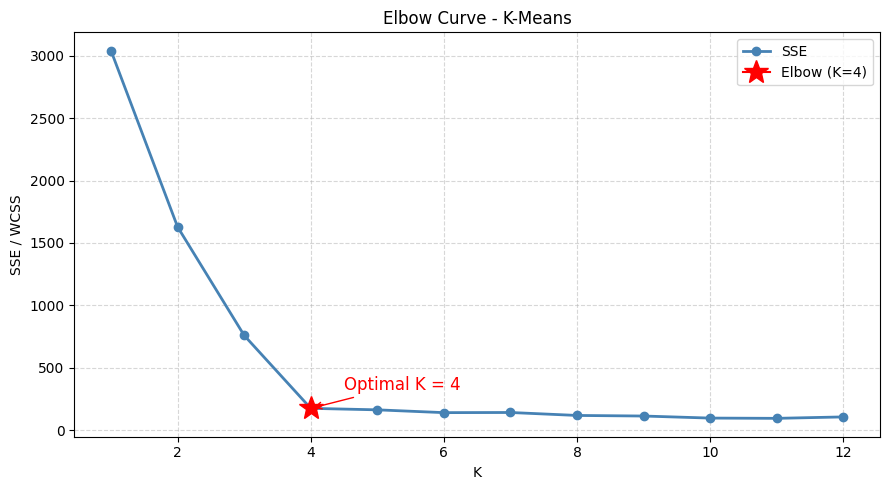

Optimal K: 4

--------- K-MEANS -----------
Iteration: 1
Points per cluster: [np.int64(114), np.int64(23), np.int64(23), np.int64(50)]
SSE per cluster: [np.float64(857.783), np.float64(10.6404), np.float64(12.7061), np.float64(46.1705)]
Total SSE: 927.2999

Iteration: 2
Points per cluster: [np.int64(111), np.int64(23), np.int64(26), np.int64(50)]
SSE per cluster: [np.float64(813.2158), np.float64(8.7276), np.float64(42.4515), np.float64(46.1705)]
Total SSE: 910.5654

Iteration: 3
Points per cluster: [np.int64(109), np.int64(31), np.int64(20), np.int64(50)]
SSE per cluster: [np.float64(778.4763), np.float64(13.572), np.float64(58.6458), np.float64(46.1705)]
Total SSE: 896.8646

Iteration: 4
Points per cluster: [np.int64(104), np.int64(41), np.int64(15), np.int64(50)]
SSE per cluster: [np.float64(711.547), np.float64(21.4033), np.float64(42.183), np.float64(46.1705)]
Total SSE: 821.3038

Iteration: 5
Points per cluster: [np.int64(72), np.int64(45), np.int64(43), np.int64(50)]
SSE per clu

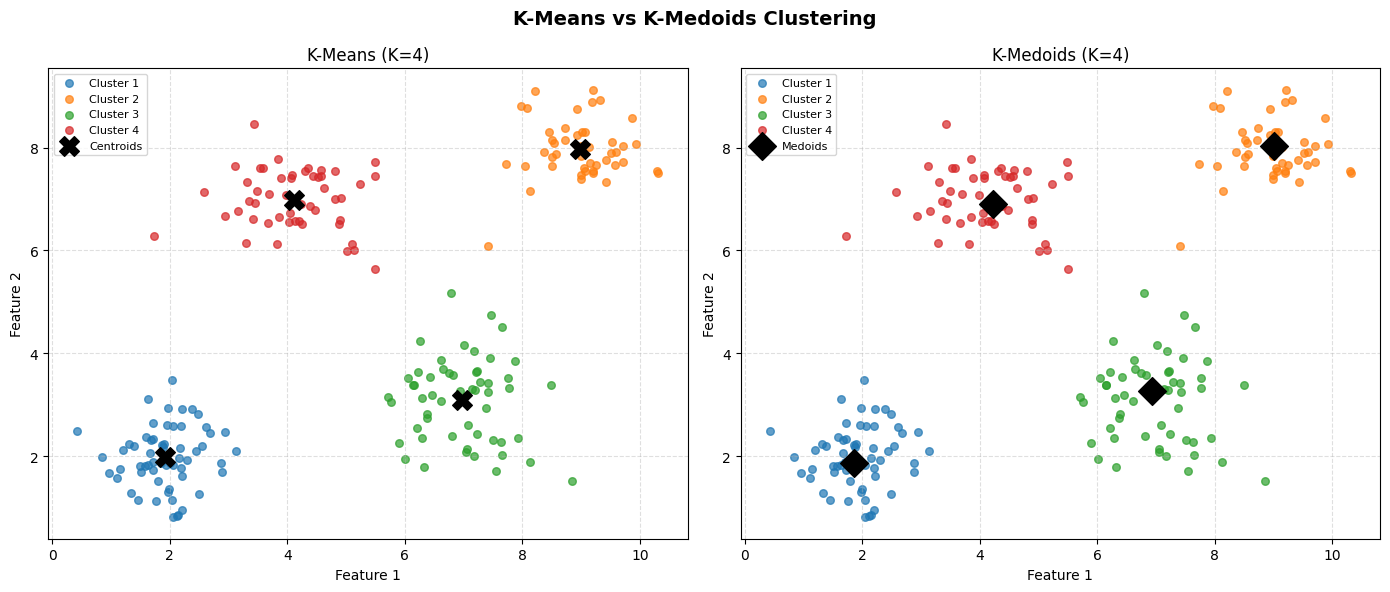

In [7]:
sse_list = []
for k in range(1, 13):
    lbl, cen, _ = kmeans(data, k)
    sse_list.append(compute_sse(data, lbl, cen))
 
deltas = np.diff(sse_list)
ratios = deltas[:-1] / deltas[1:]
optimal_k = int(np.argmax(ratios)) + 2
 
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, 13), sse_list, marker='o', color='steelblue', linewidth=2, label='SSE')
ax.plot(optimal_k, sse_list[optimal_k - 1], marker='*', markersize=18, color='red', zorder=5, label='Elbow (K=' + str(optimal_k) + ')')

ax.annotate('Optimal K = ' + str(optimal_k), xy=(optimal_k, sse_list[optimal_k - 1]),
            xytext=(optimal_k + 0.5, sse_list[optimal_k - 1] + (max(sse_list) - min(sse_list)) * 0.05),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=12, color='red')

ax.set_xlabel('K')
ax.set_ylabel('SSE / WCSS')
ax.set_title('Elbow Curve - K-Means')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("elbow_curve.png", dpi=150)
plt.show()
 
print("Optimal K:", optimal_k)
print("")
 
print("--------- K-MEANS -----------")
t0 = time.time()
km_labels, km_centers, km_history = kmeans(data, optimal_k)
km_time = time.time() - t0
 
for it, counts, c_sse, t_sse in km_history:
    print("Iteration:", it)
    print("Points per cluster:", counts)
    print("SSE per cluster:", [round(v, 4) for v in c_sse])
    print("Total SSE:", round(t_sse, 4))
    print("")
 
print("K-Means wall-clock time (seconds):", round(km_time, 6))
print("")
 
print("--------- K-MEDOIDS -----------")
t0 = time.time()
kmed_labels, kmed_medoids, kmed_medoid_idx, kmed_history = kmedoids(data, optimal_k)
kmed_time = time.time() - t0
 
for it, counts, c_sse, t_sse, midx in kmed_history:
    print("Iteration:", it)
    print("Points per cluster:", counts)
    print("SSE per cluster:", [round(v, 4) for v in c_sse])
    print("Total SSE:", round(t_sse, 4))
    print("Medoid indices:", midx.tolist())
    print("Medoid points:", data[midx].tolist())
    print("")
 
print("K-Medoids wall-clock time (seconds):", round(kmed_time, 6))
print("")
 
print("--------- COMPARATIVE ANALYSIS -----------")
print("K-Means iterations to converge:", len(km_history))
print("K-Medoids iterations to converge:", len(kmed_history))
print("K-Means final total SSE:", round(compute_sse(data, km_labels, km_centers), 4))
print("K-Medoids final total SSE:", round(compute_sse(data, kmed_labels, kmed_medoids), 4))
print("K-Means execution time (s):", round(km_time, 6))
print("K-Medoids execution time (s):", round(kmed_time, 6))
 
km_sizes = [np.sum(km_labels == i) for i in range(optimal_k)]
kmed_sizes = [np.sum(kmed_labels == i) for i in range(optimal_k)]
print("K-Means cluster sizes:", sorted(km_sizes))
print("K-Medoids cluster sizes:", sorted(kmed_sizes))
print("")
 
colors = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
ax = axes[0]
for i in range(optimal_k):
    pts = data[km_labels == i]
    ax.scatter(pts[:, 0], pts[:, 1], s=30, color=colors[i], label='Cluster ' + str(i + 1), alpha=0.7)
ax.scatter(km_centers[:, 0], km_centers[:, 1], s=200, color='black', marker='X', zorder=5, label='Centroids')
ax.set_title('K-Means (K=' + str(optimal_k) + ')')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)
 
ax = axes[1]
for i in range(optimal_k):
    pts = data[kmed_labels == i]
    ax.scatter(pts[:, 0], pts[:, 1], s=30, color=colors[i], label='Cluster ' + str(i + 1), alpha=0.7)
ax.scatter(kmed_medoids[:, 0], kmed_medoids[:, 1], s=200, color='black', marker='D', zorder=5, label='Medoids')
ax.set_title('K-Medoids (K=' + str(optimal_k) + ')')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)
 
plt.suptitle('K-Means vs K-Medoids Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("clusters_comparison.png", dpi=150)
plt.show()
 

1. Which algorithm needed more iterations to converge?
K-Means converged faster (fewer iterations). This is because it updates cluster centers by taking the mathematical mean of all points, which moves directly toward the optimal position in one step. K-Medoids is slower because it must try swapping every point in a cluster as a potential medoid and pick the best one. this is a slow, trial-and-error process that takes more steps to settle.

2. How do the final clusters compare?
Looking at the side-by-side plot, both algorithms produced identical cluster assignments . same 4 groups, same sizes (46, 50, 54, 60 points each). The clusters are also visually identical in shape and spread. The only visible difference is the center markers: K-Means centroids (X) sit at the geometric average of each cluster, while K-Medoids medoids (diamond) are actual data points, so they sit slightly off-center in some clusters.

3. Which algorithm is more suitable for this dataset?
K-Means is more suitable here. Both algorithms gave the same clusters and nearly the same SSE, but K-Means ran faster. Since the dataset has clean, well-separated, roughly spherical clusters with no extreme outliers, K-Means works perfectly well. K-Medoids would only have a real advantage if there were heavy outliers pulling centroids away ; which is not the case here.